# HiP-AD Gradient Analysis — Tier 1 / Tier 2 Visualization

Loads the per-layer probe (M3) results saved by `tools/run_gradient_analysis.py`
and renders the visualizations needed to read them.

Conventions:
- `delta = stepped_loss - baseline_loss` (positive = source's update **hurts** target)
- `variant=normalized` is the apples-to-apples comparison across layers (always α units)
- `variant=raw` keeps the natural step magnitude `α·g`; useful with `grad_norm` column
- `layer=_all` exists only when full-update probe was run; per-layer rows have specific keys

Outputs from each experiment live under:
```
<root>/
  ckpt_<tag>/
    probe/probe_per_batch.csv             # long format, all layers/sources/targets
    probe/probe_matrix_<layer>_*.csv      # source × target wide matrices
    conflict/conflict_<a>_<b>_*.csv       # M2 cosine + norm stats
  dynamics/                               # M6 across-checkpoint timeseries
  supplementary/                          # batch_size=1 deep probe (1ep)
```

## 0. Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

REPO = Path('/home/yongjae/e2e/HiP-AD')
RESULTS = REPO / 'gradient_analysis_results'

TIER1 = RESULTS / 'tier1_fixed'
TIER2 = RESULTS / 'tier2_old'

TASKS = ['det', 'map', 'motion', 'ego', 'plan']
TASK_COLORS = {
    'det':    '#e74c3c',
    'map':    '#2ecc71',
    'motion': '#3498db',
    'ego':    '#9b59b6',
    'plan':   '#f39c12',
}

mpl.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 9,
})

## 1. Loader helpers

`load_probe_long(root)` concatenates every checkpoint's `probe_per_batch.csv` with a
`ckpt` column so we can pivot/group freely. `load_probe_matrix(root, layer, ckpt, ...)`
loads a single saved source × target wide matrix when convenient.

In [2]:
CKPT_ORDER = ['1ep', '3ep', '6ep', '18ep']

def list_ckpts(root: Path) -> list[str]:
    found = sorted(p.name[len('ckpt_'):] for p in root.glob('ckpt_*'))
    return [c for c in CKPT_ORDER if c in found] + [c for c in found if c not in CKPT_ORDER]


def load_probe_long(root: Path) -> pd.DataFrame:
    """Concatenate per-batch probe rows across all ckpt_* under root."""
    frames = []
    for ckpt in list_ckpts(root):
        path = root / f'ckpt_{ckpt}' / 'probe' / 'probe_per_batch.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['ckpt'] = ckpt
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'no probe_per_batch.csv under {root}')
    out = pd.concat(frames, ignore_index=True)
    out['ckpt'] = pd.Categorical(out['ckpt'], CKPT_ORDER, ordered=True)
    return out


def load_probe_matrix(root: Path, layer: str, ckpt: str, steps: int = 1, variant: str = 'normalized') -> pd.DataFrame:
    suffix = '' if layer == '_all' else f'_{layer}'
    path = root / f'ckpt_{ckpt}' / 'probe' / f'probe_matrix{suffix}_{steps}step_{variant}.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, index_col=0)


def load_conflict(root: Path, ckpt: str) -> pd.DataFrame:
    """Concatenate M2 per-pair conflict summaries for one ckpt."""
    frames = []
    cdir = root / f'ckpt_{ckpt}' / 'conflict'
    if not cdir.exists():
        return pd.DataFrame()
    for f in sorted(cdir.glob('conflict_*_summary.csv')):
        df = pd.read_csv(f)
        df['file'] = f.name
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


tier1_long = load_probe_long(TIER1)
tier2_long = load_probe_long(TIER2)
print('tier1:', tier1_long['layer'].unique(), '|', tier1_long['ckpt'].unique().tolist())
print('tier2:', tier2_long['layer'].unique(), '|', tier2_long['ckpt'].unique().tolist())
tier1_long.head()

FileNotFoundError: no probe_per_batch.csv under /home/yongjae/e2e/HiP-AD/gradient_analysis_results/tier2_old

## 2. Tier 1 — 4 hypothesis layers

Layers tested:
- `dec5_gnn_0` — late cross-task fusion (prime suspect)
- `dec0_gnn_0` — early cross-task fusion (depth comparison)
- `dec5_ffn_0_fc1` — late per-task projection (control: should show LESS conflict)
- `fc_after` — final shared transform before heads

Variant: `normalized` for fair cross-layer comparison.

In [3]:
def affinity_matrix(df: pd.DataFrame, ckpt: str, layer: str,
                    steps: int = 1, variant: str = 'normalized',
                    metric: str = 'delta') -> pd.DataFrame:
    """Mean ΔL (or rel_delta) over batches → source × target wide matrix."""
    sub = df[(df.ckpt == ckpt) & (df.layer == layer)
             & (df.steps == steps) & (df.variant == variant)]
    if sub.empty:
        return pd.DataFrame()
    pv = sub.pivot_table(index='source_task', columns='target_task',
                          values=metric, aggfunc='mean')
    return pv.reindex(index=TASKS, columns=TASKS)


def plot_layer_panel(df: pd.DataFrame, ckpt: str, layers: list[str],
                      variant: str = 'normalized', steps: int = 1,
                      metric: str = 'delta', title_prefix: str = '',
                      vmax: float | None = None):
    """Side-by-side heatmaps, one per layer, for a single ckpt."""
    n = len(layers)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.4), squeeze=False)
    # Compute symmetric color limit per panel set unless user supplied one
    if vmax is None:
        vals = []
        for L in layers:
            m = affinity_matrix(df, ckpt, L, steps, variant, metric)
            if not m.empty:
                vals.append(np.nanmax(np.abs(m.values)))
        vmax = max(vals) if vals else 1.0
    for ax, L in zip(axes[0], layers):
        m = affinity_matrix(df, ckpt, L, steps, variant, metric)
        if m.empty:
            ax.set_title(f'{L}\n(no data)', fontsize=9)
            ax.axis('off')
            continue
        im = ax.imshow(m.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=30, ha='right')
        ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
        for i in range(len(TASKS)):
            for j in range(len(TASKS)):
                v = m.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:+.2g}', ha='center', va='center',
                             color='white' if abs(v) > vmax * 0.5 else 'black', fontsize=7)
        ax.set_title(L, fontsize=9)
        ax.set_xlabel('target')
        if ax is axes[0][0]: ax.set_ylabel('source')
    fig.suptitle(f"{title_prefix}{ckpt} — {variant}, {steps}-step ΔL_target  (red=hurts)", y=1.02)
    fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label=metric)
    plt.tight_layout()
    return fig

/tmp/ipykernel_3395585/2613526392.py:48: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label=metric)
/tmp/ipykernel_3395585/2613526392.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


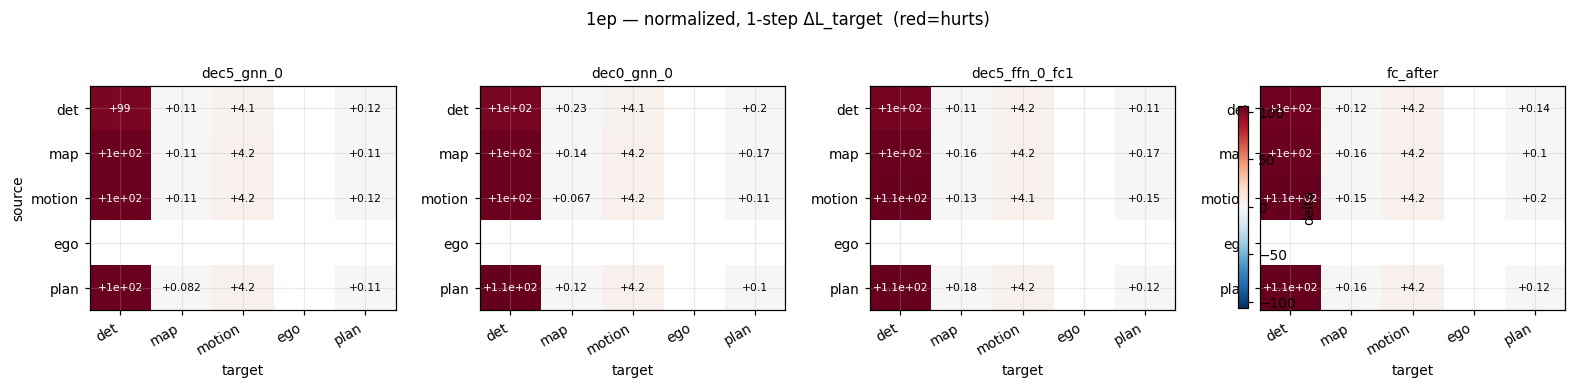

/tmp/ipykernel_3395585/2613526392.py:48: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label=metric)
/tmp/ipykernel_3395585/2613526392.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


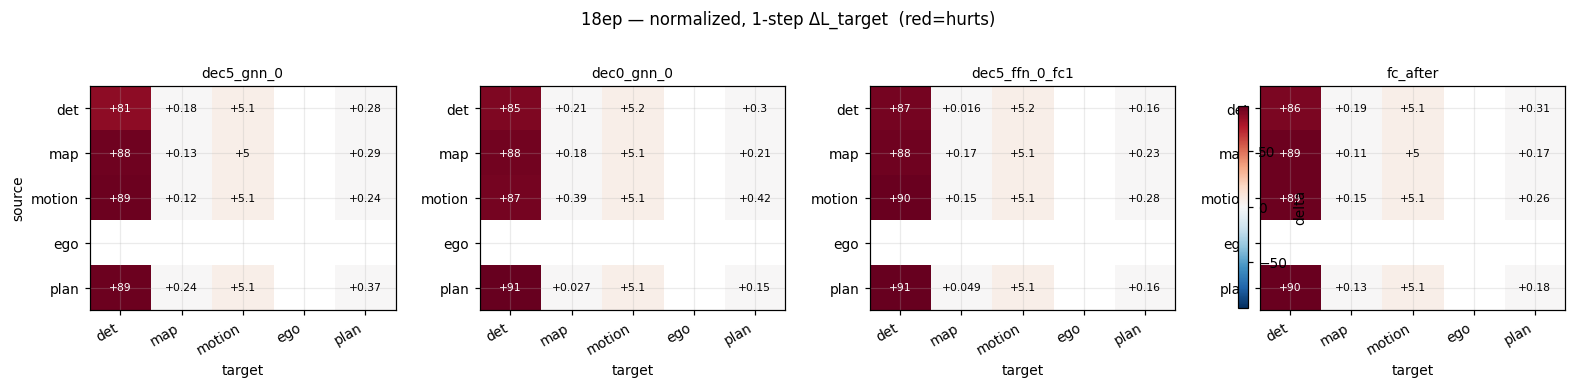

In [4]:
TIER1_LAYERS = ['dec5_gnn_0', 'dec0_gnn_0', 'dec5_ffn_0_fc1', 'fc_after']
for ck in CKPT_ORDER:
    if ck not in tier1_long['ckpt'].unique():
        continue
    plot_layer_panel(tier1_long, ck, TIER1_LAYERS,
                      variant='normalized', steps=1)
    plt.show()

### 2.1 Per-layer ΔL evolution across training

For each (source, target) pair, plot mean ΔL (with std-err over batches) across
checkpoints, one curve per layer.

Reading guide:
- Diagonal (`source == target`): should be **negative** with `normalized` variant in a
  well-behaved region (descent reduces own loss). Positive = step too aggressive or
  outside the locally convex basin.
- Off-diagonal: ΔL > 0 = `source` update hurts `target` (conflict). ΔL < 0 = cooperative.

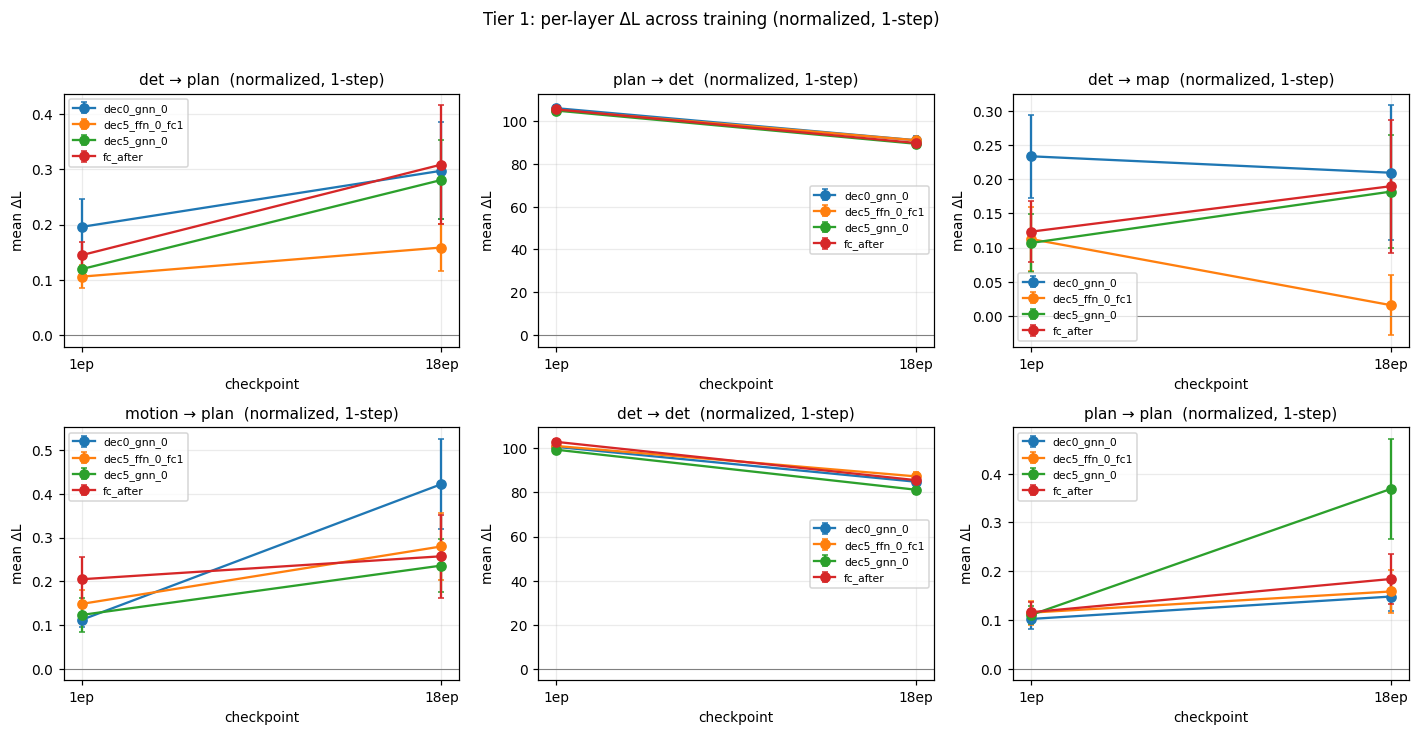

In [5]:
def plot_pair_evolution(df: pd.DataFrame, source: str, target: str,
                          layers: list[str], variant: str = 'normalized',
                          steps: int = 1, ax=None):
    sub = df[(df.source_task == source) & (df.target_task == target)
              & (df.variant == variant) & (df.steps == steps)
              & (df.layer.isin(layers))]
    if sub.empty:
        return None
    agg = sub.groupby(['layer', 'ckpt'], observed=True)['delta'].agg(['mean', 'std', 'count']).reset_index()
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.6))
    for L, g in agg.groupby('layer', observed=True):
        g = g.sort_values('ckpt')
        ax.errorbar(range(len(g)), g['mean'], yerr=g['sem'], marker='o', label=L, capsize=2)
        ax.set_xticks(range(len(g))); ax.set_xticklabels(g['ckpt'].astype(str))
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_title(f'{source} → {target}  ({variant}, {steps}-step)', fontsize=10)
    ax.set_xlabel('checkpoint'); ax.set_ylabel('mean ΔL')
    ax.legend(fontsize=7, loc='best')
    return ax

interesting_pairs = [('det', 'plan'), ('plan', 'det'), ('det', 'map'),
                      ('motion', 'plan'), ('det', 'det'), ('plan', 'plan')]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, (s, t) in zip(axes.flat, interesting_pairs):
    plot_pair_evolution(tier1_long, s, t, TIER1_LAYERS, ax=ax)
fig.suptitle('Tier 1: per-layer ΔL across training (normalized, 1-step)', y=1.02)
plt.tight_layout(); plt.show()

## 3. Tier 2 — depth scan of GNN layers

Six layers `dec0_gnn_0` … `dec5_gnn_0`. Question: at what decoder depth does
cross-task conflict accumulate the most?

In [ ]:
TIER2_LAYERS = sorted([L for L in tier2_long['layer'].unique() if L.startswith('dec') and 'gnn' in L])
depth_idx = {L: int(L.split('_')[0][len('dec'):]) for L in TIER2_LAYERS}
TIER2_LAYERS_SORTED = sorted(TIER2_LAYERS, key=depth_idx.get)
print('depth-ordered:', TIER2_LAYERS_SORTED)


def plot_depth_scan(df: pd.DataFrame, source: str, target: str,
                      ckpt: str, variant: str = 'normalized', steps: int = 1, ax=None):
    sub = df[(df.source_task == source) & (df.target_task == target)
              & (df.variant == variant) & (df.steps == steps) & (df.ckpt == ckpt)]
    if sub.empty:
        return None
    agg = sub.groupby('layer')['delta'].agg(['mean', 'std', 'count']).reset_index()
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    agg['depth'] = agg['layer'].map(lambda L: int(L.split('_')[0][len('dec'):]))
    agg = agg.sort_values('depth')
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.errorbar(agg['depth'], agg['mean'], yerr=agg['sem'], marker='o', capsize=2,
                 color=TASK_COLORS.get(source, '#444'))
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_title(f'{source} → {target}  @ {ckpt}', fontsize=10)
    ax.set_xlabel('decoder depth'); ax.set_ylabel('mean ΔL')
    ax.set_xticks(range(6))
    return ax

depth-ordered: ['dec0_gnn_0', 'dec1_gnn_0', 'dec2_gnn_0', 'dec3_gnn_0', 'dec4_gnn_0', 'dec5_gnn_0']


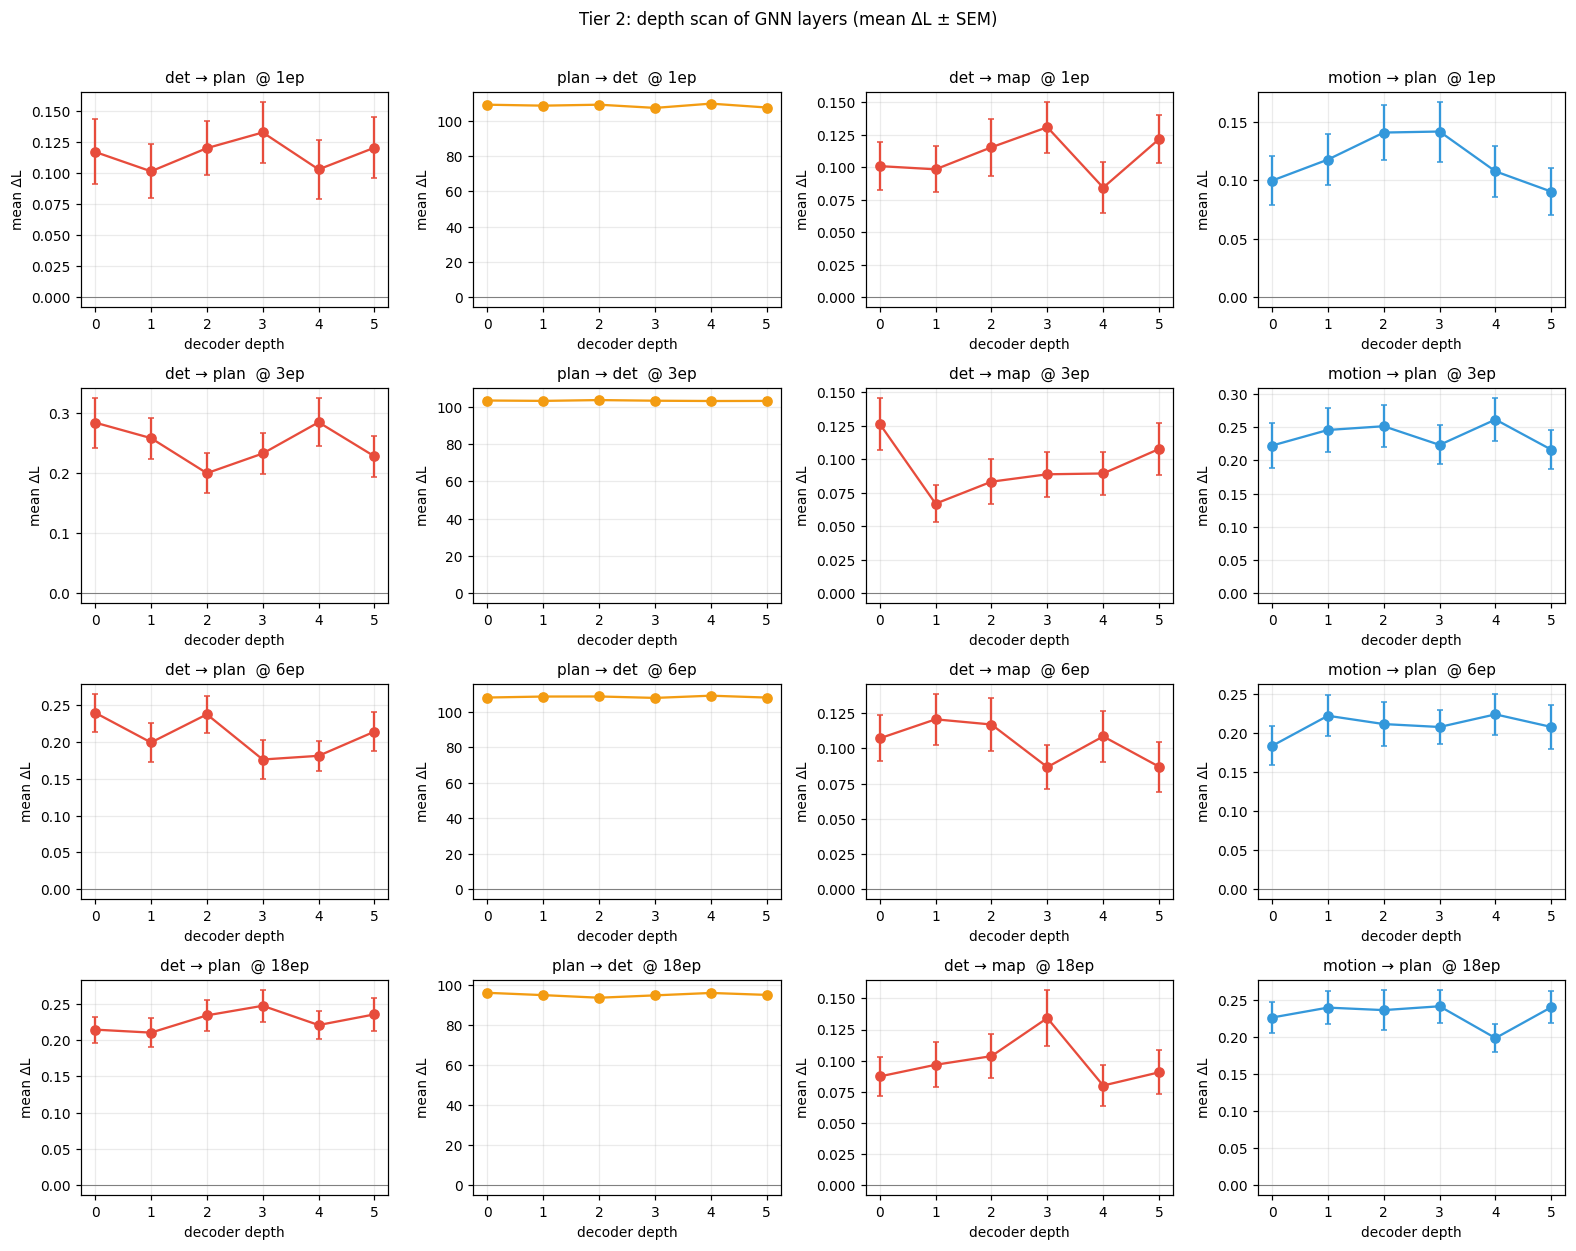

In [ ]:
# Depth scan grid: 4 ckpts × {det→plan, plan→det, det→map, det→motion}
grid_pairs = [('det', 'plan'), ('plan', 'det'), ('det', 'map'), ('motion', 'plan')]
available_ckpts = [c for c in CKPT_ORDER if c in tier2_long['ckpt'].unique()]
fig, axes = plt.subplots(len(available_ckpts), len(grid_pairs),
                          figsize=(3.6 * len(grid_pairs), 2.8 * len(available_ckpts)),
                          squeeze=False)
for r, ck in enumerate(available_ckpts):
    for c, (s, t) in enumerate(grid_pairs):
        plot_depth_scan(tier2_long, s, t, ck, ax=axes[r][c])
fig.suptitle('Tier 2: depth scan of GNN layers (mean ΔL ± SEM)', y=1.01)
plt.tight_layout(); plt.show()

/tmp/ipykernel_2921000/2613526392.py:48: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label=metric)
/tmp/ipykernel_2921000/2613526392.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


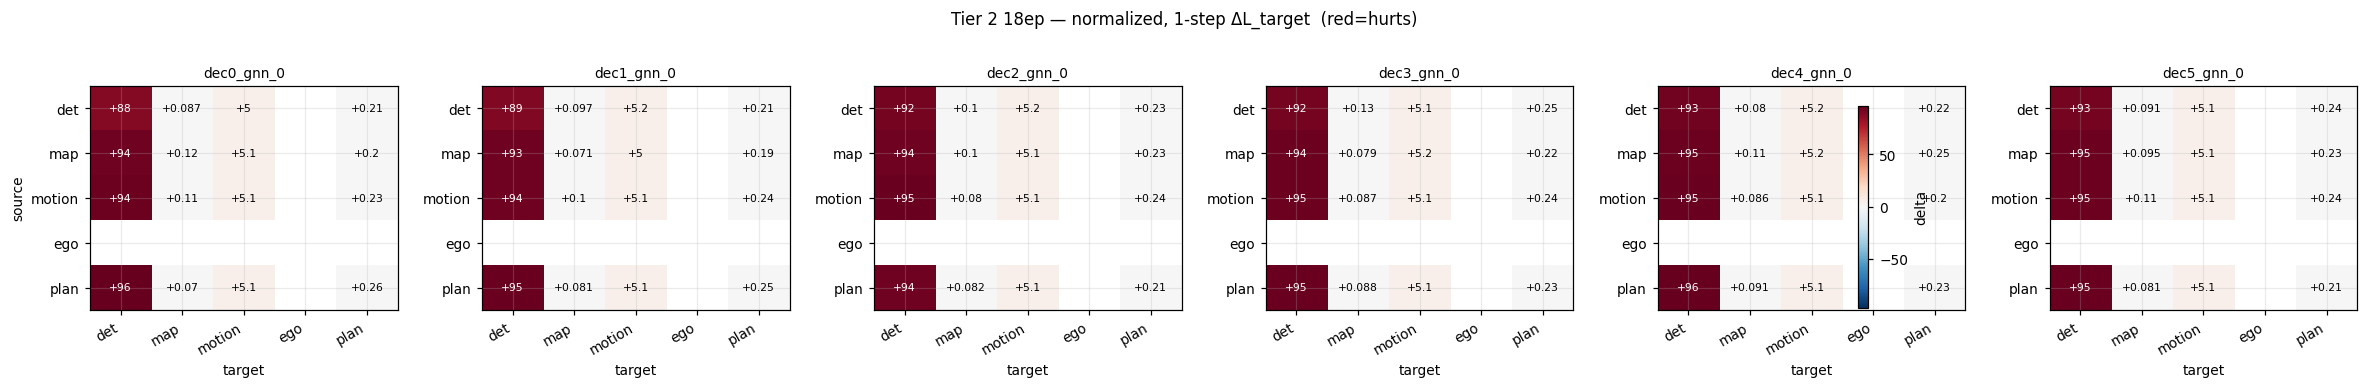

In [ ]:
# Heatmap panel: each gnn layer at the latest checkpoint
latest = available_ckpts[-1] if available_ckpts else None
if latest:
    plot_layer_panel(tier2_long, latest, TIER2_LAYERS_SORTED,
                      variant='normalized', steps=1,
                      title_prefix='Tier 2 ')
    plt.show()

## 4. Layer ranking by total interference

Aggregates a single number per layer: **mean off-diagonal |ΔL|** across all
(source ≠ target) pairs. Higher = that layer is a bigger conflict hotspot.

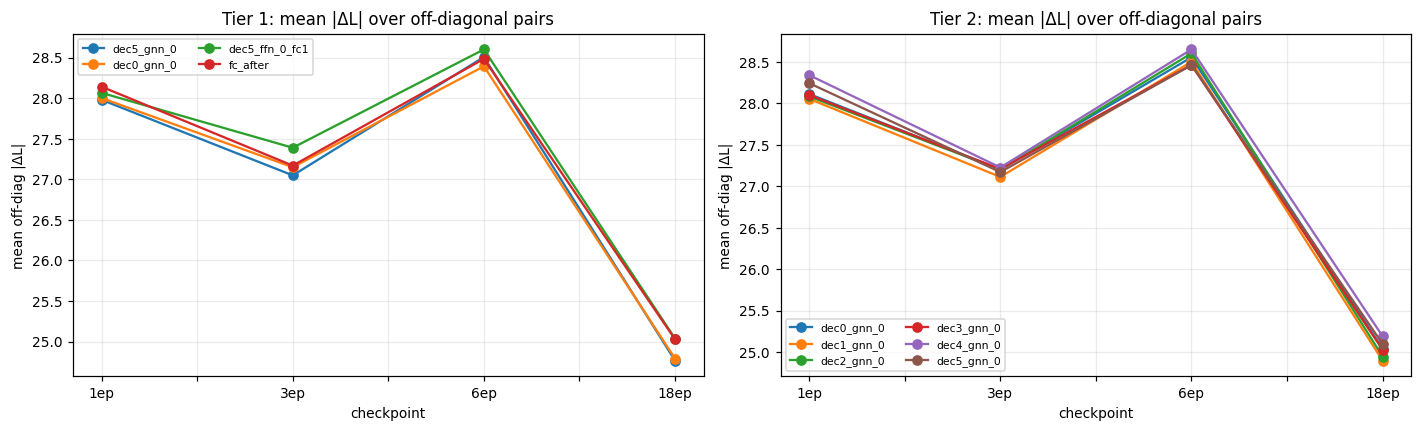

In [ ]:
def total_interference(df: pd.DataFrame, variant: str = 'normalized', steps: int = 1) -> pd.DataFrame:
    sub = df[(df.variant == variant) & (df.steps == steps)
              & (df.source_task != df.target_task)].copy()
    sub['abs_delta'] = sub['delta'].abs()
    return (sub.groupby(['ckpt', 'layer'], observed=True)['abs_delta']
             .mean().rename('mean_abs_delta_offdiag').reset_index())


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (label, df, layers) in zip(axes,
                                   [('Tier 1', tier1_long, TIER1_LAYERS),
                                    ('Tier 2', tier2_long, TIER2_LAYERS_SORTED)]):
    ti = total_interference(df)
    ti = ti[ti['layer'].isin(layers)]
    pv = ti.pivot(index='ckpt', columns='layer', values='mean_abs_delta_offdiag').reindex(columns=layers)
    pv.plot(marker='o', ax=ax)
    ax.set_title(f'{label}: mean |ΔL| over off-diagonal pairs')
    ax.set_ylabel('mean off-diag |ΔL|'); ax.set_xlabel('checkpoint')
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 5. Cross-reference with M2 (cosine conflict)

M2 saved per-(group_key, batch) cosine-similarity stats between task gradient pairs.
We pick a pair (e.g. det↔plan), pull the cosine summary at one checkpoint, and
overlay it against the per-layer ΔL signal to see whether the layers with
negative cosine are also the ones with high ΔL.

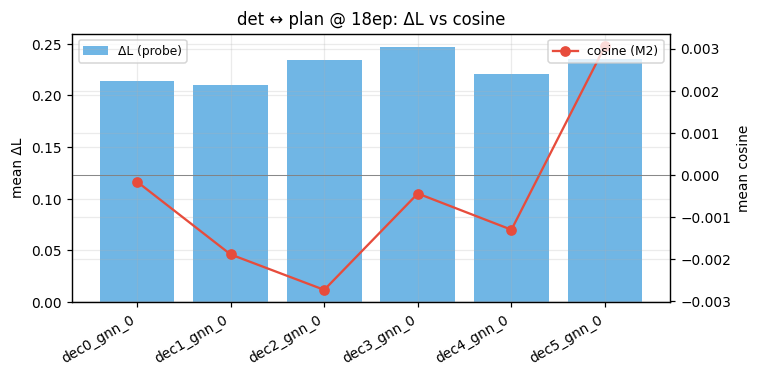

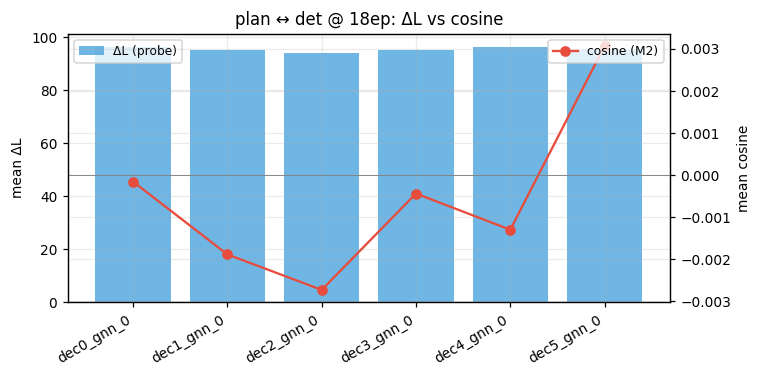

In [ ]:
def load_pair_conflict(root: Path, ckpt: str, a: str, b: str) -> pd.DataFrame:
    p = root / f'ckpt_{ckpt}' / 'conflict' / f'conflict_{a}_{b}_summary.csv'
    if not p.exists():
        # try reversed order
        p = root / f'ckpt_{ckpt}' / 'conflict' / f'conflict_{b}_{a}_summary.csv'
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)


def cosine_vs_dl(probe_long: pd.DataFrame, conflict_root: Path,
                  ckpt: str, source: str, target: str,
                  layers: list[str], variant: str = 'normalized'):
    cos_df = load_pair_conflict(conflict_root, ckpt, source, target)
    if cos_df.empty:
        print(f'no conflict csv for {source}/{target}')
        return
    cos_layer_col = next((c for c in ['group_key', 'group', 'layer'] if c in cos_df.columns), None)
    cos_metric = next((c for c in ['mean_cosine', 'cosine_mean', 'mean_cos', 'cos_mean'] if c in cos_df.columns), None)
    if cos_layer_col is None or cos_metric is None:
        print('cosine csv columns:', list(cos_df.columns))
        return
    dl = (probe_long[(probe_long.ckpt == ckpt) & (probe_long.source_task == source)
                       & (probe_long.target_task == target) & (probe_long.variant == variant)
                       & (probe_long.layer.isin(layers))]
                .groupby('layer')['delta'].mean())
    cos = cos_df.set_index(cos_layer_col)[cos_metric]
    common = dl.index.intersection(cos.index)
    if len(common) == 0:
        print('no overlapping layer keys between probe and conflict csv')
        print('probe layers:', list(dl.index))
        print('conflict keys:', list(cos.index)[:10])
        return
    fig, ax1 = plt.subplots(figsize=(7, 3.5))
    ax2 = ax1.twinx()
    ax1.bar(common, [dl[k] for k in common], alpha=0.7, color='#3498db', label='ΔL (probe)')
    ax2.plot(common, [cos[k] for k in common], color='#e74c3c', marker='o', label='cosine (M2)')
    ax2.axhline(0, color='gray', lw=0.6)
    ax1.set_ylabel('mean ΔL'); ax2.set_ylabel('mean cosine')
    ax1.set_xticks(range(len(common))); ax1.set_xticklabels(common, rotation=30, ha='right')
    ax1.set_title(f'{source} ↔ {target} @ {ckpt}: ΔL vs cosine')
    ax1.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)
    plt.tight_layout(); plt.show()


if available_ckpts:
    cosine_vs_dl(tier2_long, TIER2, available_ckpts[-1], 'det', 'plan', TIER2_LAYERS_SORTED)
    cosine_vs_dl(tier2_long, TIER2, available_ckpts[-1], 'plan', 'det', TIER2_LAYERS_SORTED)

## 6. M6 dynamics quick view

Across-checkpoint cosine / helpful-fraction time series for full-update gradients.

In [ ]:
for label, root in [('tier1', TIER1), ('tier2', TIER2)]:
    for fname in ['cos_dynamics.csv', 'helpful_dynamics.csv']:
        p = root / 'dynamics' / fname
        if not p.exists():
            continue
        df = pd.read_csv(p)
        # heuristic: pivot any column-set with task-pair info
        print(f'\n=== {label}/{fname} ({len(df)} rows) ===')
        print(df.head())


=== tier1/cos_dynamics.csv (1344 rows) ===
   epoch         pair            group  mean_cos  conflict_ratio
0    1.0  motion|plan  backbone_layer1  0.001369            0.51
1    1.0  motion|plan  backbone_layer2  0.000873            0.53
2    1.0  motion|plan  backbone_layer3  0.004200            0.48
3    1.0  motion|plan  backbone_layer4  0.003286            0.46
4    1.0  motion|plan    backbone_stem -0.022546            0.56

=== tier1/helpful_dynamics.csv (48 rows) ===
   epoch        pair  helpful_ratio
0    1.0     det→map         0.2175
1    1.0  det→motion         0.0000
2    1.0    det→plan         0.3125
3    1.0     map→det         0.0000
4    1.0  map→motion         0.0000

=== tier2/cos_dynamics.csv (1344 rows) ===
   epoch         pair            group  mean_cos  conflict_ratio
0    1.0  motion|plan  backbone_layer1  0.005793            0.49
1    1.0  motion|plan  backbone_layer2  0.001860            0.56
2    1.0  motion|plan  backbone_layer3  0.005103            0.54


## 7. Free-form exploration

Common queries:
```python
# Mean ΔL for a single pair across layers
tier2_long[(tier2_long.source_task=='det') & (tier2_long.target_task=='plan')
            & (tier2_long.variant=='normalized') & (tier2_long.steps==1)]\
    .groupby(['ckpt','layer'], observed=True)['delta'].mean().unstack('layer')

# Self-loss sanity (diagonal should be ~0 or negative for normalized)
tier1_long[(tier1_long.source_task==tier1_long.target_task)
            & (tier1_long.variant=='normalized') & (tier1_long.steps==1)]\
    .groupby(['ckpt','layer','source_task'], observed=True)['delta'].mean()

# Compare normalized vs raw for one cell
tier1_long[(tier1_long.source_task=='det') & (tier1_long.target_task=='plan')
            & (tier1_long.steps==1)].groupby(['ckpt','layer','variant'], observed=True)['delta'].mean()
```

In [ ]:
# Self-loss diagonal sanity check
diag = tier1_long[(tier1_long.source_task == tier1_long.target_task)
                    & (tier1_long.variant == 'normalized') & (tier1_long.steps == 1)]
diag.groupby(['ckpt', 'layer', 'source_task'], observed=True)['delta'].mean().unstack('source_task')

source_task                 det       map    motion      plan
ckpt layer                                                   
1ep  dec0_gnn_0      104.660431  0.115051  4.058004  0.111023
     dec5_ffn_0_fc1  104.476662  0.120497  4.105446  0.135493
     dec5_gnn_0      103.584403  0.120397  4.071220  0.087745
     fc_after        106.324888  0.111039  4.098104  0.119622
3ep  dec0_gnn_0      101.939491  0.092600  5.367989  0.254608
     dec5_ffn_0_fc1  100.897885  0.081756  5.387228  0.240012
     dec5_gnn_0      100.408256  0.068520  5.273054  0.275284
     fc_after        102.563005  0.096789  5.294576  0.278879
6ep  dec0_gnn_0      107.866881  0.079158  4.894277  0.201579
     dec5_ffn_0_fc1  107.037345  0.096567  4.976801  0.263672
     dec5_gnn_0      105.150501  0.082900  4.908546  0.272573
     fc_after        107.580739  0.099795  4.863621  0.257786
18ep dec0_gnn_0       89.936069  0.101651  5.134290  0.258316
     dec5_ffn_0_fc1   90.348539  0.093020  5.162826  0.229263
     dec5_gnn_0       88.303054  0.119967  5.090110  0.203744
     fc_after         92.225556  0.125875  5.118430  0.235263